In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde
import corner, h5py, os, sys, emcee
from datetime import datetime
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# ======================
# MATPLOTLIB STYLE
# ======================
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams["figure.facecolor"] = "white"
plt.rc("text", usetex=False)
plt.rc("font", family="serif", size=20)
plt.rc("axes", linewidth=1.5)
plt.rc("axes", labelsize=18)
plt.rc("xtick", labelsize=12, direction="in")
plt.rc("ytick", labelsize=12, direction="in")
plt.rc("xtick", top=True)
plt.rc("ytick", right=True)
plt.rc("xtick.minor", visible=True)
plt.rc("ytick.minor", visible=True)
plt.rc("xtick.major", size=8, pad=4)
plt.rc("xtick.minor", size=4, pad=4)
plt.rc("ytick.major", size=8)
plt.rc("ytick.minor", size=4)
plt.rc("legend", fontsize=10)

# ======================
# DATA GENERATION
# ======================

def generate_data(N=50, regime="small"):
    true = np.random.normal(0, 1, size=2)
    m, b = true

    x = np.linspace(0, 10, N)

    if regime == "small":
        x_err = 0.01
        y_err = 0.1
    elif regime == "large_x":
        x_err = 2.0
        y_err = 0.1
    elif regime == "large_y":
        x_err = 0.01
        y_err = 2.0
    else:
        x_err = 2.0
        y_err = 2.0

    x_obs = x + np.random.normal(0, x_err, size=N)
    y = m * x + b
    y_obs = y + np.random.normal(0, y_err, size=N)

    return x_obs, y_obs, x_err*np.ones_like(x), y_err*np.ones_like(x), true

# ======================
# MODEL
# ======================

def log_prior(theta):
    eps = 1e-6
    if np.any(np.abs(theta) < eps):
        return -np.inf
    return -np.sum(np.log(np.abs(theta)))


def log_likelihood(theta, x, y, xerr, yerr):
    m, b = theta
    model = m * x + b
    sigma2 = yerr**2 + (m**2 * xerr**2)
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(sigma2))


def log_probability(theta, x, y, xerr, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, xerr, yerr)

# ======================
# HELPER: MULTIMODAL CHECK
# ======================

def detect_multimodal(samples_1d):
    kde0 = gaussian_kde(samples_1d)
    kde = gaussian_kde(samples_1d, bw_method = kde0.factor*2)
    xs = np.linspace(samples_1d.min(), samples_1d.max(), 200)
    ys = kde(xs)
    peaks = np.where((ys[1:-1] > ys[:-2]) & (ys[1:-1] > ys[2:]))[0]
    true_peaks = peaks[ys[peaks]>0.05*np.max(ys)]
    return len(true_peaks)

from scipy.stats import ks_2samp

# KS-based stability test
def ks_stability_test(chain, flat_samples, tau = 100):
    """
    Returns per-parameter p-values comparing:
    1) 4 chunks of the chain
    2) last 100 vs previous 100 samples
    """
    ndim = flat_samples.shape[1]

    pvals_chunks = []
    splits = np.array_split(flat_samples[len(flat_samples)//2:], 4)

    for i in range(ndim):
        # pairwise KS across chunks (take worst p-value)
        pvals = []
        for j in range(len(splits)-1):
            p = ks_2samp(splits[j][:, i], splits[j+1][:, i]).pvalue
            pvals.append(p)
        pvals_chunks.append(np.min(pvals))

    # tail test: last 100 vs previous 100
    tail = flat_samples[-2*tau:]
    if len(tail) < 2*tau:
        pvals_tail = [np.nan]*ndim
    else:
        pvals_tail = []
        for i in range(ndim):
            p = ks_2samp(tail[:tau, i], tail[tau:, i]).pvalue
            pvals_tail.append(p)

    return np.array(pvals_chunks), np.array(pvals_tail)


# ======================
# ONLINE SAMPLING + DIAGNOSTICS
# ======================

def run_adaptive_mcmc(x, y, xerr, yerr, ndim = 2, nwalkers=32, max_steps=50000, filename="chain.h5", eval_interval=100):
    
    
    if os.path.exists(filename):
        os.remove(filename)
    else:
        print(f"The file {filename} does not exist")
        
    backend = emcee.backends.HDFBackend(filename)
    backend.reset(nwalkers, ndim)

    pos = np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, xerr, yerr), backend=backend)

    old_tau = np.inf * np.ones(ndim)
    tau_history = []
    iter_history = []

    for sample in sampler.sample(pos, iterations=max_steps, progress=True):

        if sampler.iteration % eval_interval != 0:
            continue

        chain = sampler.get_chain()
        n = chain.shape[0]

        try:
            tau = sampler.get_autocorr_time(tol=0)
        except:
            continue

        tau_history.append(tau)
        iter_history.append(n)

        ess = n / tau

        af = sampler.acceptance_fraction
        var = np.var(chain[-100:], axis=0)

        stuck = (af < 0.025) | (var.mean(axis=1) < 1e-6)

        # -------- WALKER REPAIR --------
        if np.any(stuck):
            print("\n[WARNING] Repairing stuck walkers:", np.where(stuck)[0])
            current_pos = sample.coords
            good = ~stuck
            mean_good = np.mean(current_pos[good], axis=0)
            current_pos[stuck] = mean_good + 1e-3 * np.random.randn(np.sum(stuck), ndim)
            sample.coords = current_pos

        # -------- MULTIMODAL DETECTION --------
        flat = sampler.get_chain(discard=max(0, n//2), flat=True)
        multimodal_peaks = np.array([detect_multimodal(flat[:, i]) for i in range(ndim)])

        # --------- CONVERGENCE ----------
        tau_stable = np.all(np.abs(tau - old_tau) / tau < 0.05)
        enough_samples = np.all(n > 40 * tau)
        enough_ess = np.all(ess > 100)
        
         # -------- KS STABILITY TEST --------
        ks_chunks, ks_tail = ks_stability_test(chain, flat)

        print("\n====================== DIAGNOSTICS ======================")
        print(f"Iteration: {n}")
        print("--------------------------------------------------------")
        print("Autocorrelation time (tau):", np.round(tau, 2))
        print(f"Autocorrelation time (tau) change since last checkpoint {np.round(100*np.abs(tau - old_tau) / tau, 2)} %")
        print(" -> Want stable tau (change <5%) and N > 40*tau")
        print("ESS:", ess)
        print(" -> Want ESS > 100 for reliable posteriors") 
        print("Acceptance fraction:", af.mean())
        print(" -> Ideal range ~0.2-0.5")
        print("Stuck walkers:", np.sum(stuck))
        print("Multimodal flags:", multimodal_peaks>1)
        if np.any(multimodal_peaks>1):
            print("Number of peaks in distribution:", multimodal_peaks)
            
        print(" -> True indicates possible multiple posterior modes")
        
        print("KS p-values (4-part chain):", ks_chunks)
        print("KS p-values (tail test):", ks_tail)
        
        print("========================================================")

        make_summary_figure(flat, chain, filename, labels = ['slope', 'offset'], iter_hist = it_hist, tau_hist = tau_hist)
        if tau_stable and enough_samples and enough_ess:
            print("\n[CONVERGED] Stopping early.")
            break

        old_tau = tau
        
    return sampler, np.array(iter_history), np.array(tau_history)

# ======================
# PLOTTING
# ======================
            #nrow,ncol for upper right, flipped for lower left
layouts = {1: (1,1),
          2: (2,1),
          3: (2,2),
          4: (2,2),
          5: (3,2),
          6: (3,2),
          7: (4,2),
          8: (4,2),
          9: (3,3),
          10: (4,3),
          11: (4,3),
          12: (4,3),
          13: (4,4),
          14: (4,4),
          15: (4,4),
          16: (4,4)
         }

def make_summary_figure(flat_samples, chain, filename, labels = None, iter_hist=None, tau_hist=None):
    steps = flat_samples.shape[0]
    ndim = flat_samples.shape[1]
    nwalkers = len(chain[0,:,0])
    layout = layouts[ndim]
    
    fig_corner = corner.corner(flat_samples, labels = labels, titles =labels, quantiles = [0.16, 0.50, 0.84], title_quantiles = [0.16, 0.50, 0.84])

    fig = plt.figure(figsize=(10*np.sqrt(ndim), 10*np.sqrt(ndim)))
    gs = fig.add_gridspec(2, 2)

    # TRACES
    subgs = gs[0, 1].subgridspec(layout[0], layout[1])
    for i in range(ndim):
        ax_trace = fig.add_subplot(subgs[i])
        ax_trace.plot(chain[:, :, i], 'k', alpha=0.2/np.sqrt(nwalkers))
        if labels:
            ax_trace.set_title(labels[i])
        ax_trace.set_xlabel('Iteration')
        percentiles = np.percentile(chain[-1000:, :, i], [0.1, 99.9])
        ax_trace.set_ylim(percentiles)
    
    # POSTERIOR STABILITY
    splits = np.array_split(flat_samples, 4)
    subgs = gs[1, 0].subgridspec(layout[0], layout[1])
    for i in range(ndim):
        ax = fig.add_subplot(subgs[i])
        xs = np.linspace(np.min(flat_samples[:, i]), np.max(flat_samples[:, i]), 200)
        for j, s in enumerate(splits):
            kde = gaussian_kde(s[:, i])
            ax.plot(xs, kde(xs), alpha=0.3, label = f'{j}')
        if labels:
            ax.set_title(labels[i])
        ax.legend()
        
    # TAU HISTORY
    ax_tau = fig.add_subplot(gs[1, 1])
    if tau_hist is not None:
        for i in range(ndim):
            if labels:
                ax_tau.plot(iter_hist, tau_hist[:, i], label = labels[i])
            else:
                ax_tau.plot(iter_hist, tau_hist[:, i])
                
        ax_tau.set_title("Autocorrelation time")
        ax_tau.set_xlabel('Iteration')
        ax_tau.set_ylabel(r'$\tau$')
        
        ax_tau.plot(iter_hist, iter_hist/40, 'k--',  label = r'Convergence criterion (N=40*$\tau$)')
        ax_tau.legend()
    
    

    import io
    with h5py.File(filename, "a") as f:
        if f"figures_{steps}" not in f:
            f.create_group(f"figures_{steps}")

        buf1 = io.BytesIO()
        fig_corner.savefig(buf1, format="png")
        f[f"figures_{steps}"].create_dataset("corner", data=np.frombuffer(buf1.getvalue(), dtype='uint8'))

        buf2 = io.BytesIO()
        fig.savefig(buf2, format="png")
        f[f"figures_{steps}"].create_dataset("summary", data=np.frombuffer(buf2.getvalue(), dtype='uint8'))

    plt.close(fig)
    plt.close(fig_corner)

# ======================
# MAIN
# ======================
plt.close('all')
x, y, xerr, yerr, true = generate_data(regime="small")
filename = 'chain.h5'
f = 2
sampler, it_hist, tau_hist = run_adaptive_mcmc(x, y, xerr*f, yerr*f, eval_interval = 200, filename = filename)

chain = sampler.get_chain()
flat = sampler.get_chain(discard=chain.shape[0]//5, thin=1, flat=True)

print("\nSaved full diagnostic summary figure + chain to HDF5")


  0%|▎                                                                  | 224/50000 [00:01<05:38, 147.03it/s]


====================== DIAGNOSTICS ======================
Iteration: 200
--------------------------------------------------------
Autocorrelation time (tau): [14.15 17.5 ]
Autocorrelation time (tau) change since last checkpoint [inf inf] %
 -> Want stable tau (change <5%) and N > 40*tau
ESS: [14.13327996 11.42617625]
 -> Want ESS > 100 for reliable posteriors
Acceptance fraction: 0.6335937500000001
 -> Ideal range ~0.2-0.5
Stuck walkers: 0
Multimodal flags: [False False]
 -> True indicates possible multiple posterior modes
KS p-values (4-part chain): [0.04457247 0.24405688]
KS p-values (tail test): [0.46950645 0.58300906]


  1%|▌                                                                  | 415/50000 [00:02<06:14, 132.53it/s]


====================== DIAGNOSTICS ======================
Iteration: 400
--------------------------------------------------------
Autocorrelation time (tau): [16.2  21.74]
Autocorrelation time (tau) change since last checkpoint [12.65 19.49] %
 -> Want stable tau (change <5%) and N > 40*tau
ESS: [24.69147717 18.39789009]
 -> Want ESS > 100 for reliable posteriors
Acceptance fraction: 0.67015625
 -> Ideal range ~0.2-0.5
Stuck walkers: 0
Multimodal flags: [False False]
 -> True indicates possible multiple posterior modes
KS p-values (4-part chain): [2.97281348e-07 2.06078021e-16]
KS p-values (tail test): [0.70205698 0.81541471]


  1%|▊                                                                  | 618/50000 [00:04<06:17, 130.73it/s]

...

  5%|███▍                                                              | 2634/50000 [00:18<06:46, 116.63it/s]


====================== DIAGNOSTICS ======================
Iteration: 2600
--------------------------------------------------------
Autocorrelation time (tau): [20.29 27.03]
Autocorrelation time (tau) change since last checkpoint [0.35 0.41] %
 -> Want stable tau (change <5%) and N > 40*tau
ESS: [128.15774726  96.17946731]
 -> Want ESS > 100 for reliable posteriors
Acceptance fraction: 0.7092548076923078
 -> Ideal range ~0.2-0.5
Stuck walkers: 0
Multimodal flags: [False False]
 -> True indicates possible multiple posterior modes
KS p-values (4-part chain): [1.77172765e-14 1.17376352e-30]
KS p-values (tail test): [0.81541471 0.15483867]


  6%|███▋                                                              | 2800/50000 [00:19<05:30, 142.98it/s]


====================== DIAGNOSTICS ======================
Iteration: 2800
--------------------------------------------------------
Autocorrelation time (tau): [20.64 27.29]
Autocorrelation time (tau) change since last checkpoint [1.69 0.95] %
 -> Want stable tau (change <5%) and N > 40*tau
ESS: [135.68848543 102.59068167]
 -> Want ESS > 100 for reliable posteriors
Acceptance fraction: 0.7089174107142857
 -> Ideal range ~0.2-0.5
Stuck walkers: 0
Multimodal flags: [False False]
 -> True indicates possible multiple posterior modes
KS p-values (4-part chain): [1.79143951e-12 7.07568170e-10]
KS p-values (tail test): [0.28194163 0.9084105 ]

[CONVERGED] Stopping early.



Saved full diagnostic summary figure + chain to HDF5


In [ ]:
chain.shape

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import io
from PIL import Image


def load_figure_from_hdf5(filename, key):
    with h5py.File(filename, "r") as f:
        data = f["figures"][key][:]
    
    buf = io.BytesIO(data.tobytes())
    img = Image.open(buf)
    return img


def show_saved_figures(filename="chain.h5"):
    corner_img = load_figure_from_hdf5(filename, "corner")
    summary_img = load_figure_from_hdf5(filename, "summary")

    # Display
    plt.figure(figsize=(8, 8))
    plt.imshow(corner_img)
    plt.axis("off")
    plt.title("Corner Plot")

    plt.figure(figsize=(8, 8))
    plt.imshow(summary_img)
    plt.axis("off")
    plt.title("Summary Diagnostics")

    plt.show()



show_saved_figures("chain.h5")

In [39]:
help(corner.corner)

Help on function corner in module corner.corner:

corner(data, bins=20, *, range=None, axes_scale='linear', weights=None, color=None, hist_bin_factor=1, smooth=None, smooth1d=None, labels=None, label_kwargs=None, titles=None, show_titles=False, title_quantiles=None, title_fmt='.2f', title_kwargs=None, truths=None, truth_color='#4682b4', scale_hist=False, quantiles=None, verbose=False, fig=None, max_n_ticks=5, top_ticks=False, use_math_text=False, reverse=False, labelpad=0.0, hist_kwargs=None, group='posterior', var_names=None, filter_vars=None, coords=None, divergences=False, divergences_kwargs=None, labeller=None, **hist2d_kwargs)
    Make a *sick* corner plot showing the projections of a data set in a
    multi-dimensional space. kwargs are passed to hist2d() or used for
    `matplotlib` styling.
    
    Parameters
    ----------
    data : obj
        Any object that can be converted to an ``arviz.InferenceData`` object.
        Refer to documentation of ``arviz.convert_to_dataset`

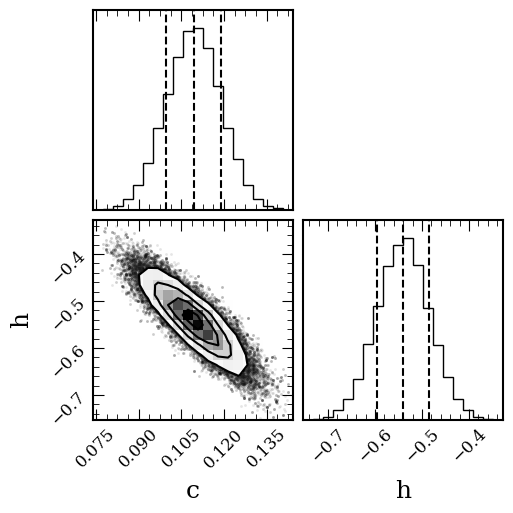

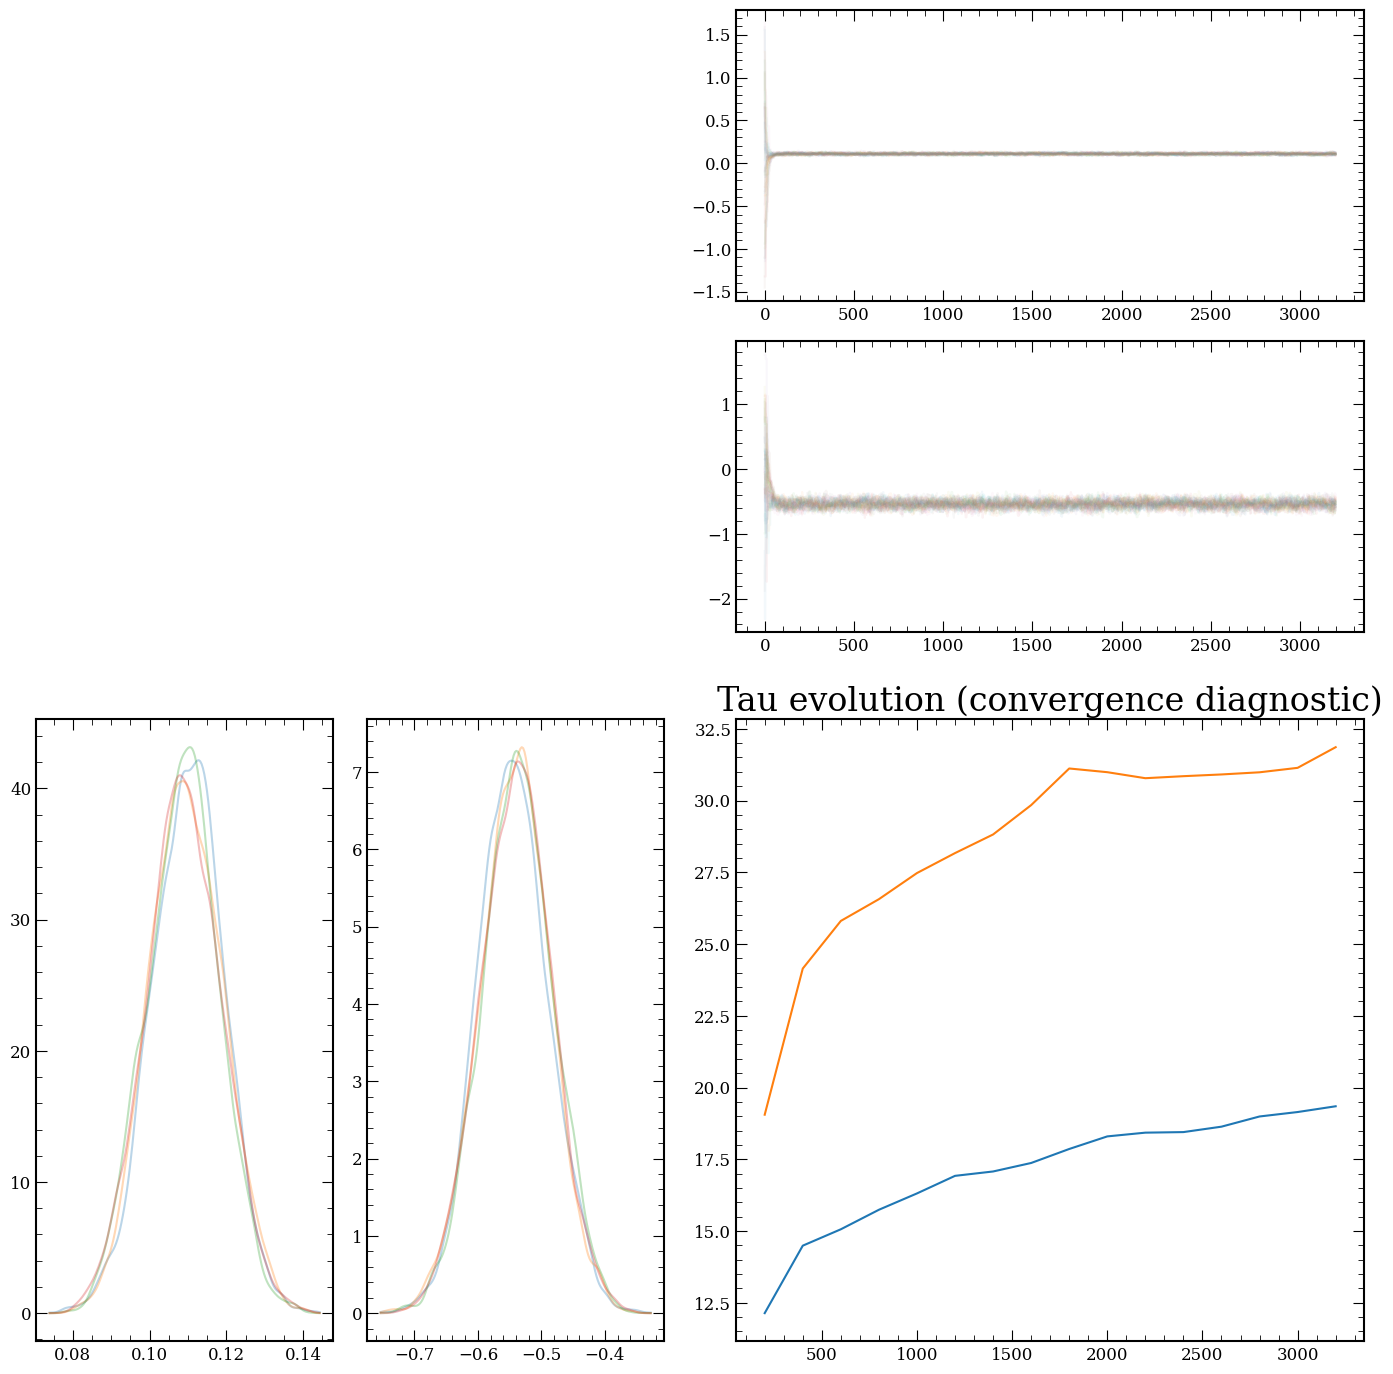

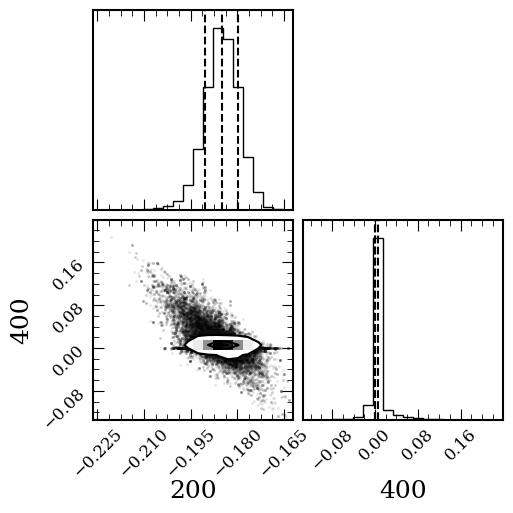

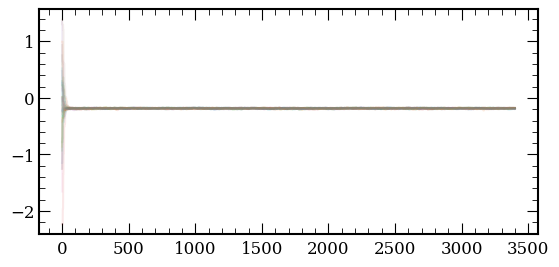

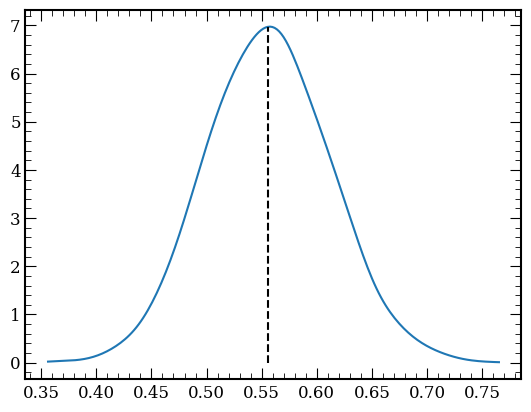

In [38]:
def detect_multimodal(samples_1d):
    kde0 = gaussian_kde(samples_1d)
    kde = gaussian_kde(samples_1d, bw_method = kde0.factor*2)
    xs = np.linspace(samples_1d.min(), samples_1d.max(), 200)
    ys = kde(xs)
    peaks = np.where((ys[1:-1] > ys[:-2]) & (ys[1:-1] > ys[2:]))[0]
    true_peaks = peaks[ys[peaks]>0.05*np.max(ys)]
    return true_peaks, ys, xs

plt.figure()
peaks, ys, xs = detect_multimodal(flat[:,1])
plt.plot(xs, ys)
plt.vlines(xs[peaks], 0, np.max(ys), color = 'k', linestyle = 'dashed')
plt.show()

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde
import corner, h5py, os, sys, emcee, io
from datetime import datetime
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# ======================
# MATPLOTLIB STYLE
# ======================
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams["figure.facecolor"] = "white"
plt.rc("text", usetex=False)
plt.rc("font", family="serif", size=20)
plt.rc("axes", linewidth=1.5)
plt.rc("axes", labelsize=18)
plt.rc("xtick", labelsize=12, direction="in")
plt.rc("ytick", labelsize=12, direction="in")
plt.rc("xtick", top=True)
plt.rc("ytick", right=True)
plt.rc("xtick.minor", visible=True)
plt.rc("ytick.minor", visible=True)
plt.rc("xtick.major", size=8, pad=4)
plt.rc("xtick.minor", size=4, pad=4)
plt.rc("ytick.major", size=8)
plt.rc("ytick.minor", size=4)
plt.rc("legend", fontsize=10)

# ======================
# DATA GENERATION
# ======================

def generate_data(N=50, regime="small"):
    true = np.random.normal(0, 1, size=2)
    m, b = true
    x = np.linspace(0, 10, N)
    if regime == "small":
        x_err, y_err = 0.01, 0.1
    elif regime == "large_x":
        x_err, y_err = 2.0, 0.1
    elif regime == "large_y":
        x_err, y_err = 0.01, 2.0
    else:
        x_err, y_err = 2.0, 2.0
    x_obs = x + np.random.normal(0, x_err, size=N)
    y     = m * x + b
    y_obs = y + np.random.normal(0, y_err, size=N)
    return x_obs, y_obs, x_err * np.ones_like(x), y_err * np.ones_like(x), true

# ======================
# MODEL
# ======================

def log_prior(theta):
    eps = 1e-6
    if np.any(np.abs(theta) < eps):
        return -np.inf
    return -np.sum(np.log(np.abs(theta)))

def log_likelihood(theta, x, y, xerr, yerr):
    m, b    = theta
    model   = m * x + b
    sigma2  = yerr**2 + (m**2 * xerr**2)
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(sigma2))

def log_probability(theta, x, y, xerr, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, xerr, yerr)

# ======================
# DIAGNOSTICS
# ======================

def detect_multimodal(samples_1d):
    kde0 = gaussian_kde(samples_1d)
    kde  = gaussian_kde(samples_1d, bw_method=kde0.factor * 2)
    xs   = np.linspace(samples_1d.min(), samples_1d.max(), 200)
    ys   = kde(xs)
    peaks      = np.where((ys[1:-1] > ys[:-2]) & (ys[1:-1] > ys[2:]))[0]
    true_peaks = peaks[ys[peaks] > 0.05 * np.max(ys)]
    return len(true_peaks)

from scipy.stats import ks_2samp

def ks_stability_test(chain, flat_samples, tau=100):
    """
    Returns per-parameter p-values comparing:
      1) 4 consecutive chunks of the second half of flat_samples
      2) last tau vs previous tau samples (tail test)
    """
    ndim   = flat_samples.shape[1]
    splits = np.array_split(flat_samples[len(flat_samples) // 2:], 4)

    pvals_chunks = []
    for i in range(ndim):
        pvals = [ks_2samp(splits[j][:, i], splits[j+1][:, i]).pvalue
                 for j in range(len(splits) - 1)]
        pvals_chunks.append(np.max(pvals))

    tail = flat_samples[-2 * tau:]
    if len(tail) < 2 * tau:
        pvals_tail = [np.nan] * ndim
    else:
        pvals_tail = [ks_2samp(tail[:tau, i], tail[tau:, i]).pvalue
                      for i in range(ndim)]

    return np.array(pvals_chunks), np.array(pvals_tail)

def compute_rhat(chain):
    """
    Gelman-Rubin R-hat statistic.
    chain: (nsteps, nwalkers, ndim)
    R-hat ~ 1.0 means converged; values > 1.01 suggest lack of convergence.
    """
    nsteps, nwalkers, ndim = chain.shape
    rhat = np.zeros(ndim)
    for i in range(ndim):
        chains_i   = chain[:, :, i].T          # (nwalkers, nsteps)
        n          = nsteps
        W          = np.mean(np.var(chains_i, axis=1, ddof=1))
        B          = n * np.var(np.mean(chains_i, axis=1), ddof=1)
        var_hat    = (n - 1) / n * W + B / n
        rhat[i]    = np.sqrt(var_hat / W) if W > 0 else np.nan
    return rhat

def format_diagnostics(n, tau, old_tau, ess, af, stuck, multimodal_peaks,
                        ks_chunks, ks_tail, rhat, labels=None):
    """Build the full diagnostic string; both printed and saved to HDF5."""
    def pname(i):
        return labels[i] if labels and i < len(labels) else f"param_{i}"

    lines = [
        f"\n{'='*54} DIAGNOSTICS {'='*54}",
        f"Iteration : {n}",
        f"{'-'*120}",
        f"Autocorrelation time (tau)         : {np.round(tau, 2)}",
        f"Tau change since last checkpoint   : {np.round(100 * np.abs(tau - old_tau) / np.where(old_tau == np.inf, 1, old_tau), 2)} %",
        f"  -> Want stable tau (change <5%) and N > 40*tau",
        f"ESS                                : {np.round(ess, 1)}",
        f"  -> Want ESS > 100 for reliable posteriors",
        f"Acceptance fraction (mean)         : {af.mean():.3f}",
        f"  -> Ideal range ~0.2-0.5",
        f"Stuck walkers                      : {np.sum(stuck)}",
        f"Multimodal flags                   : {multimodal_peaks > 1}",
    ]
    if np.any(multimodal_peaks > 1):
        lines.append(f"  Number of peaks                  : {multimodal_peaks}")
    lines += [
        f"  -> True indicates possible multiple posterior modes",
        f"",
        f"KS p-values (4-chunk stability)    : { {pname(i): float(f'{ks_chunks[i]:.3f}') for i in range(len(ks_chunks))} }",
        f"KS p-values (tail test)            : { {pname(i): float(f'{ks_tail[i]:.3f}') for i in range(len(ks_tail))} }",
        f"  -> p > 0.05 suggests the distribution is stationary across chunks / the tail",
        f"",
        f"R-hat (Gelman-Rubin)               : { {pname(i): float(f'{rhat[i]:.4f}') for i in range(len(rhat))} }",
        f"  -> R-hat < 1.01 indicates good convergence; values > 1.1 suggest chains have not mixed",
        f"{'='*120}",
    ]
    return "\n".join(lines)

# ======================
# LAYOUT HELPER
# ======================

layouts = {
    1:  (1, 1),  2:  (2, 1),  3:  (2, 2),  4:  (2, 2),
    5:  (3, 2),  6:  (3, 2),  7:  (4, 2),  8:  (4, 2),
    9:  (3, 3),  10: (4, 3),  11: (4, 3),  12: (4, 3),
    13: (4, 4),  14: (4, 4),  15: (4, 4),  16: (4, 4),
}

# ======================
# SUMMARY FIGURE
# ======================

def make_summary_figure(flat_samples, chain, filename,
                        labels=None, iter_hist=None, tau_hist=None,
                        ks_chunks=None, ks_tail=None):

    # FIX: nsteps should come from chain (nsteps, nwalkers, ndim),
    # NOT flat_samples which has shape (nsteps*nwalkers, ndim)
    nsteps, nwalkers, ndim = chain.shape
    nrows, ncols = layouts[ndim]

    # FIX: halved figure size
    size = 4 * np.sqrt(ndim)

    fig = plt.figure(figsize=(2 * size, 2 * size), constrained_layout=True)
    subfigs = fig.subfigures(2, 2, wspace=0.05, hspace=0.05)

    # ---- Upper-left: corner plot ----
    # FIX: titles=labels + title_fmt to show median +/- sigma
    corner.corner(
        flat_samples,
        labels=labels,
        titles=labels,
        quantiles=[0.16, 0.50, 0.84],
        title_quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_fmt=".3f",
        fig=subfigs[0, 0],
        label_kwargs={"fontsize": 12},
        title_kwargs={"fontsize": 12},
    )
    subfigs[0, 0].suptitle("Posterior corner", fontsize=11, y=1.03, x = 0.55)

    # ---- Upper-right: traces ----
    axs_trace = subfigs[0, 1].subplots(nrows, ncols, squeeze=False)
    subfigs[0, 1].suptitle("Walker traces", fontsize=12)
    for idx in range(ndim):
        r, c = divmod(idx, ncols)
        ax   = axs_trace[r, c]
        ax.plot(chain[:, :, idx], "k", alpha=0.2 / np.sqrt(nwalkers), rasterized=True)
        ax.set_title(labels[idx] if labels else f"param {idx}", fontsize=8)
        ax.set_xlabel("Iteration", fontsize=7)
        ax.tick_params(labelsize=7)
        lo, hi = np.percentile(chain[-1000:, :, idx], [0.1, 99.9])
        ax.set_ylim(lo, hi)
    for idx in range(ndim, nrows * ncols):
        r, c = divmod(idx, ncols)
        axs_trace[r, c].set_visible(False)

    # ---- Lower-left: posterior stability + KS annotations ----
    axs_stab = subfigs[1, 0].subplots(nrows, ncols, squeeze=False)
    subfigs[1, 0].suptitle("Posterior stability (2nd-half chunks)", fontsize=12)
    splits = np.array_split(flat_samples[len(flat_samples) // 2:], 4)
    for idx in range(ndim):
        r, c = divmod(idx, ncols)
        ax   = axs_stab[r, c]
        xs   = np.linspace(flat_samples[:, idx].min(), flat_samples[:, idx].max(), 200)
        for j, s in enumerate(splits):
            kde = gaussian_kde(s[:, idx])
            ax.plot(xs, kde(xs), alpha=0.6, label=f"chunk {j}")
        ax.set_title(labels[idx] if labels else f"param {idx}", fontsize=12)
        ax.tick_params(labelsize=7)
        if ks_chunks is not None and ks_tail is not None:
            ann = (f"KS-chunk p={ks_chunks[idx]:.3f}\n"
                   f"KS-tail  p={ks_tail[idx]:.3f}")
            ax.text(0.02, 0.97, ann,
                    transform=ax.transAxes, fontsize=6, va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
        ax.legend(fontsize=12, loc="upper right")
    for idx in range(ndim, nrows * ncols):
        r, c = divmod(idx, ncols)
        axs_stab[r, c].set_visible(False)

    # ---- Lower-right: tau history + horizontal dotted lines at max tau ----
    ax_tau = subfigs[1, 1].subplots(1, 1)
    subfigs[1, 1].suptitle("Autocorrelation time", fontsize=12)
    if tau_hist is not None and iter_hist is not None:
        tau_hist_arr  = np.array(tau_hist)   # (n_checkpoints, ndim)
        iter_hist_arr = np.array(iter_hist)
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        max_taus = []
        for i in range(ndim):
            lbl   = labels[i] if labels else f"param {i}"
            col   = colors[i % len(colors)]
            line, = ax_tau.plot(iter_hist_arr, tau_hist_arr[:, i], label=lbl, color=col)

            # FIX: dotted horizontal line at the maximum tau reached for this dimension
            max_tau = tau_hist_arr[:, i].max()
            max_taus.append(max_tau)
            ax_tau.axhline(max_tau, color=col, linestyle=":", linewidth=1.0, alpha=0.7)

        ax_tau.plot(iter_hist_arr, iter_hist_arr / 50, "k--",
                    label=r"Convergence criterion (N = 50$\tau$)")
        ax_tau.set_xlabel("Iteration", fontsize=12)
        ax_tau.set_ylabel(r"$\tau$", fontsize=12)
        ax_tau.set_ylim(2, np.max(max_taus)*1.05)
        ax_tau.tick_params(labelsize=12)
        ax_tau.legend(fontsize=12)
                

    # ---- Save to HDF5 ----
    with h5py.File(filename, "a") as f:
        grp = f.require_group(f"figures_{nsteps}")
        buf_main = io.BytesIO()
        fig.savefig(buf_main, format="png", dpi=120, bbox_inches="tight")
        if "summary" in grp:
            del grp["summary"]
        grp.create_dataset("summary", data=np.frombuffer(buf_main.getvalue(), dtype="uint8"))

    plt.close(fig)

# ======================
# ONLINE SAMPLING + DIAGNOSTICS
# ======================

def run_adaptive_mcmc(x, y, xerr, yerr, ndim=2, nwalkers=32,
                      max_steps=50000, filename="chain.h5", eval_interval=100):

    if os.path.exists(filename):
        os.remove(filename)

    backend = emcee.backends.HDFBackend(filename)
    backend.reset(nwalkers, ndim)

    pos     = np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability,
                                     args=(x, y, xerr, yerr), backend=backend)

    old_tau      = np.inf * np.ones(ndim)
    tau_history  = []
    iter_history = []

    for sample in sampler.sample(pos, iterations=max_steps, progress=True):

        if sampler.iteration % eval_interval != 0:
            continue

        chain = sampler.get_chain()
        n     = chain.shape[0]

        try:
            tau = sampler.get_autocorr_time(tol=0)
        except Exception:
            continue

        tau_history.append(tau.copy())
        iter_history.append(n)

        ess = n / tau
        af  = sampler.acceptance_fraction
        var = np.var(chain[-100:], axis=0)

        stuck = (af < 0.025) | (var.mean(axis=1) < 1e-5)

        # -------- WALKER REPAIR --------
        if np.any(stuck):
            current_pos       = sample.coords
            good              = ~stuck
            mean_good         = np.mean(current_pos[good], axis=0)
            current_pos[stuck] = mean_good + 1e-3 * np.random.randn(np.sum(stuck), ndim)
            sample.coords     = current_pos

        flat             = sampler.get_chain(discard=max(0, n // 2), flat=True)
        multimodal_peaks = np.array([detect_multimodal(flat[:, i]) for i in range(ndim)])
        ks_chunks, ks_tail = ks_stability_test(chain, flat, tau=200)
        rhat             = compute_rhat(chain)

        # -------- CONVERGENCE --------
        tau_stable     = np.all(np.abs(tau - old_tau) / np.where(old_tau == np.inf, 1, old_tau) < 0.05)
        enough_samples = np.all(n > 50 * tau) #the same criterion seen two different ways
        enough_ess     = np.all(ess > 50)

        # -------- FORMAT + PRINT + SAVE DIAGNOSTICS --------
        diag_str = format_diagnostics(
            n, tau, old_tau, ess, af, stuck,
            multimodal_peaks, ks_chunks, ks_tail, rhat,
            labels=["slope", "offset"]
        )
        print(diag_str)

        with h5py.File(filename, "a") as f:
            grp = f.require_group(f"figures_{n}")
            if "diagnostics" in grp:
                del grp["diagnostics"]
            grp.create_dataset(
                "diagnostics",
                data=np.bytes_(diag_str.encode("utf-8"))
            )

        make_summary_figure(
            flat, chain, filename,
            labels=["slope", "offset"],
            iter_hist=iter_history,
            tau_hist=tau_history,
            ks_chunks=ks_chunks,
            ks_tail=ks_tail,
        )

        if tau_stable and enough_samples and enough_ess:
            print(f"\n[CONVERGED] Stopping early at iteration {n}.")
            break

        old_tau = tau.copy()

    return sampler, np.array(iter_history), np.array(tau_history)

# ======================
# MAIN
# ======================
plt.close("all")
x, y, xerr, yerr, true = generate_data(regime="small")
filename = "chain.h5"
f = 1
sampler, it_hist, tau_hist = run_adaptive_mcmc(
    x, y, xerr * f, yerr * f,
    eval_interval=200, filename=filename
)

chain = sampler.get_chain()
flat  = sampler.get_chain(discard=chain.shape[0] // 5, thin=1, flat=True)
print(f"\nSaved full diagnostic summary + chain to {filename}")

  0%|▎                                                                   | 191/50000 [00:01<08:38, 96.08it/s]


====================================================== DIAGNOSTICS ======================================================
Iteration : 200
------------------------------------------------------------------------------------------------------------------------
Autocorrelation time (tau)         : [12.68 14.78]
Tau change since last checkpoint   : [inf inf] %
  -> Want stable tau (change <5%) and N > 40*tau
ESS                                : [15.8 13.5]
  -> Want ESS > 100 for reliable posteriors
Acceptance fraction (mean)         : 0.508
  -> Ideal range ~0.2-0.5
Stuck walkers                      : 12
Multimodal flags                   : [False False]
  -> True indicates possible multiple posterior modes

KS p-values (4-chunk stability)    : {'slope': 0.094, 'offset': 0.078}
KS p-values (tail test)            : {'slope': 0.178, 'offset': 0.466}
  -> p > 0.05 suggests the distribution is stationary across chunks / the tail

R-hat (Gelman-Rubin)               : {'slope': 1.0383, 'offse

/home/cj1223/.conda/envs/torch-env/lib/python3.10/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
  1%|▌                                                                  | 390/50000 [00:05<06:37, 124.81it/s]


====================================================== DIAGNOSTICS ======================================================
Iteration : 400
------------------------------------------------------------------------------------------------------------------------
Autocorrelation time (tau)         : [13.68 17.78]
Tau change since last checkpoint   : [ 7.92 20.3 ] %
  -> Want stable tau (change <5%) and N > 40*tau
ESS                                : [29.2 22.5]
  -> Want ESS > 100 for reliable posteriors
Acceptance fraction (mean)         : 0.472
  -> Ideal range ~0.2-0.5
Stuck walkers                      : 22
Multimodal flags                   : [False False]
  -> True indicates possible multiple posterior modes

KS p-values (4-chunk stability)    : {'slope': 0.112, 'offset': 0.06}
KS p-values (tail test)            : {'slope': 0.793, 'offset': 0.713}
  -> p > 0.05 suggests the distribution is stationary across chunks / the tail

R-hat (Gelman-Rubin)               : {'slope': 1.0183, 'of

  1%|▊                                                                  | 596/50000 [00:10<06:19, 130.31it/s]

...


====================================================== DIAGNOSTICS ======================================================
Iteration : 1000
------------------------------------------------------------------------------------------------------------------------
Autocorrelation time (tau)         : [14.55 20.74]
Tau change since last checkpoint   : [0.56 2.35] %
  -> Want stable tau (change <5%) and N > 40*tau
ESS                                : [68.7 48.2]
  -> Want ESS > 100 for reliable posteriors
Acceptance fraction (mean)         : 0.356
  -> Ideal range ~0.2-0.5
Stuck walkers                      : 26
Multimodal flags                   : [False False]
  -> True indicates possible multiple posterior modes

KS p-values (4-chunk stability)    : {'slope': 0.0, 'offset': 0.0}
KS p-values (tail test)            : {'slope': 0.27, 'offset': 1.0}
  -> p > 0.05 suggests the distribution is stationary across chunks / the tail

R-hat (Gelman-Rubin)               : {'slope': 1.0073, 'offset': 

  2%|█▌                                                                | 1190/50000 [00:23<06:38, 122.38it/s]


====================================================== DIAGNOSTICS ======================================================
Iteration : 1200
------------------------------------------------------------------------------------------------------------------------
Autocorrelation time (tau)         : [14.76 21.68]
Tau change since last checkpoint   : [1.41 4.56] %
  -> Want stable tau (change <5%) and N > 40*tau
ESS                                : [81.3 55.4]
  -> Want ESS > 100 for reliable posteriors
Acceptance fraction (mean)         : 0.326
  -> Ideal range ~0.2-0.5
Stuck walkers                      : 29
Multimodal flags                   : [False  True]
  Number of peaks                  : [1 2]
  -> True indicates possible multiple posterior modes

KS p-values (4-chunk stability)    : {'slope': 0.0, 'offset': 0.0}
KS p-values (tail test)            : {'slope': 0.866, 'offset': 0.713}
  -> p > 0.05 suggests the distribution is stationary across chunks / the tail

R-hat (Gelman-Rubin

  2%|█▌                                                                 | 1200/50000 [00:26<17:48, 45.67it/s]


[CONVERGED] Stopping early at iteration 1200.

Saved full diagnostic summary + chain to chain.h5


Found 6 checkpoint(s) in 'chain.h5'.
Displaying 6: ['200', '400', '600', '800', '1000', '1200'] iterations.



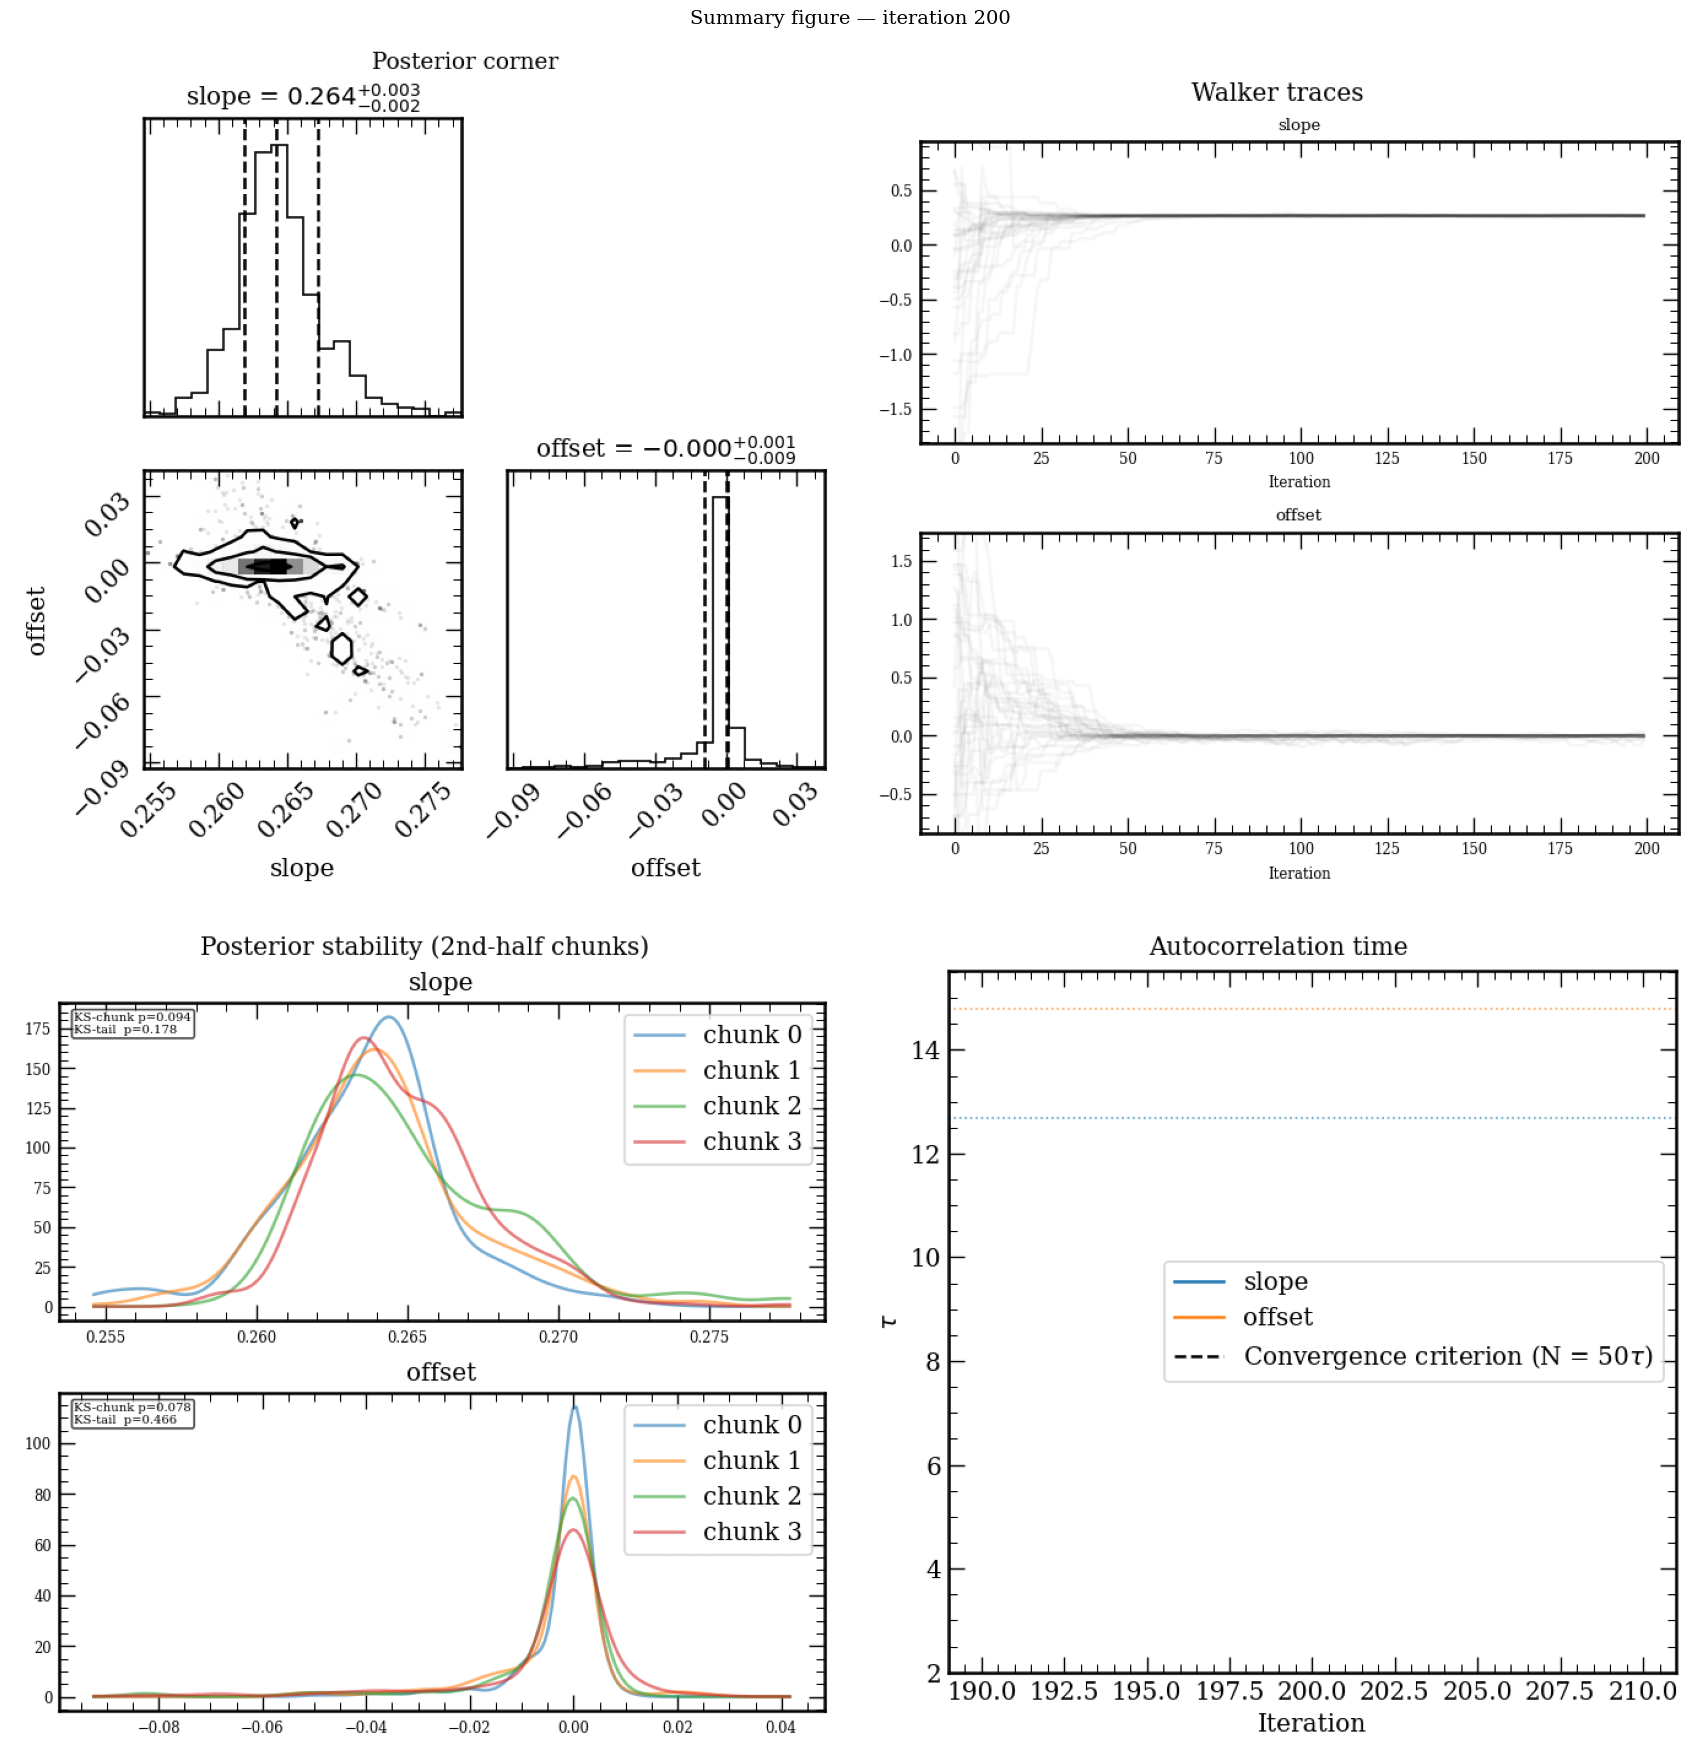

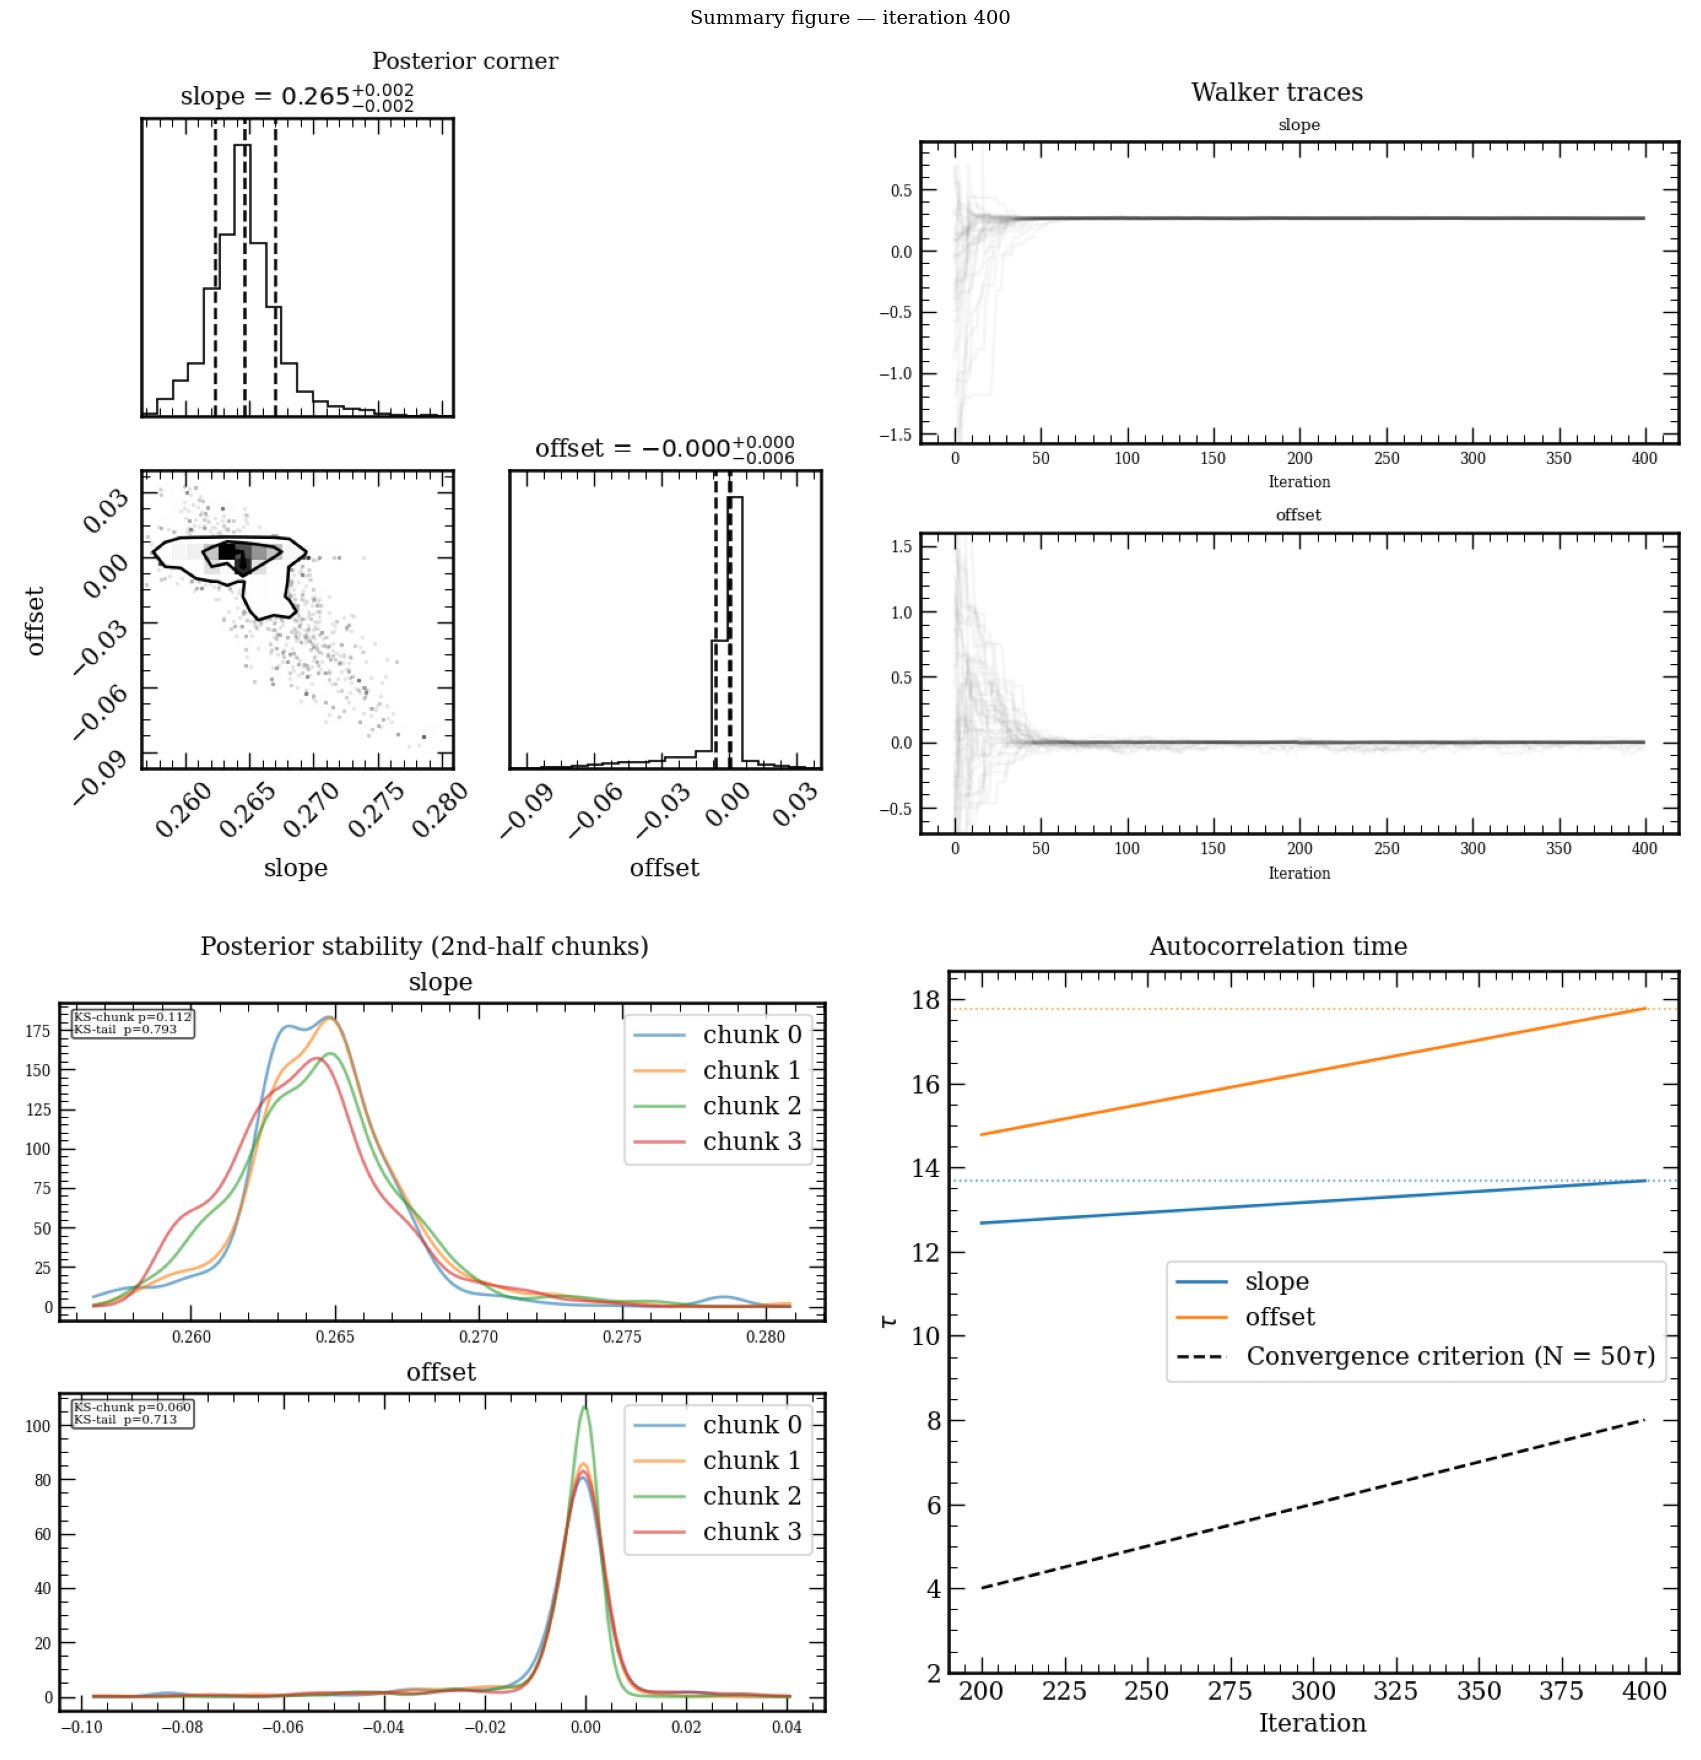

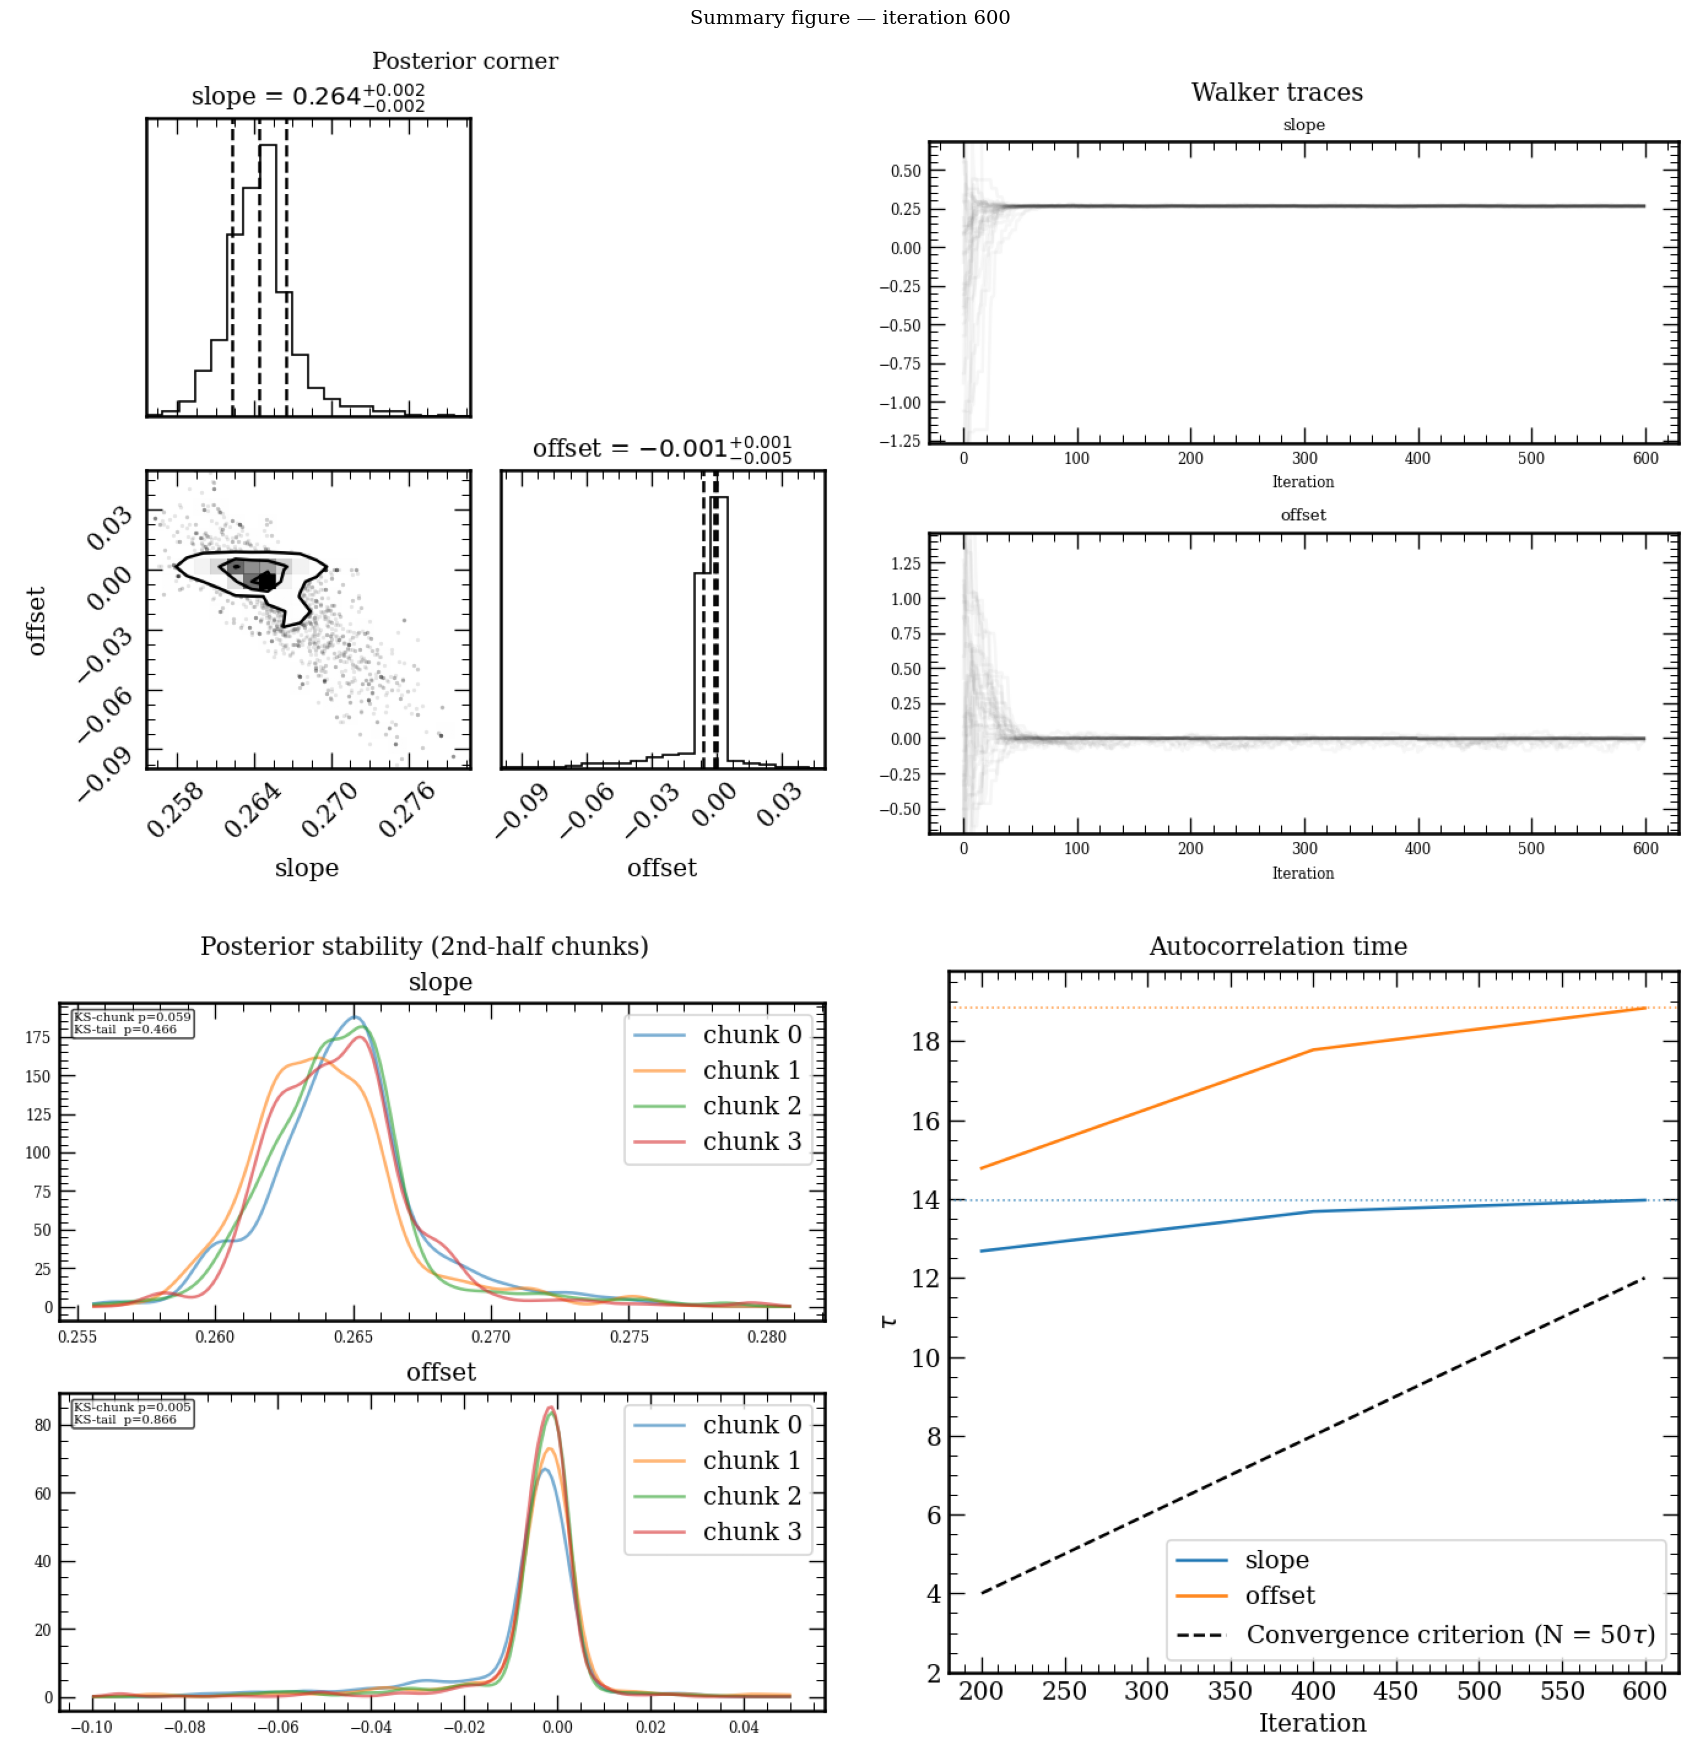

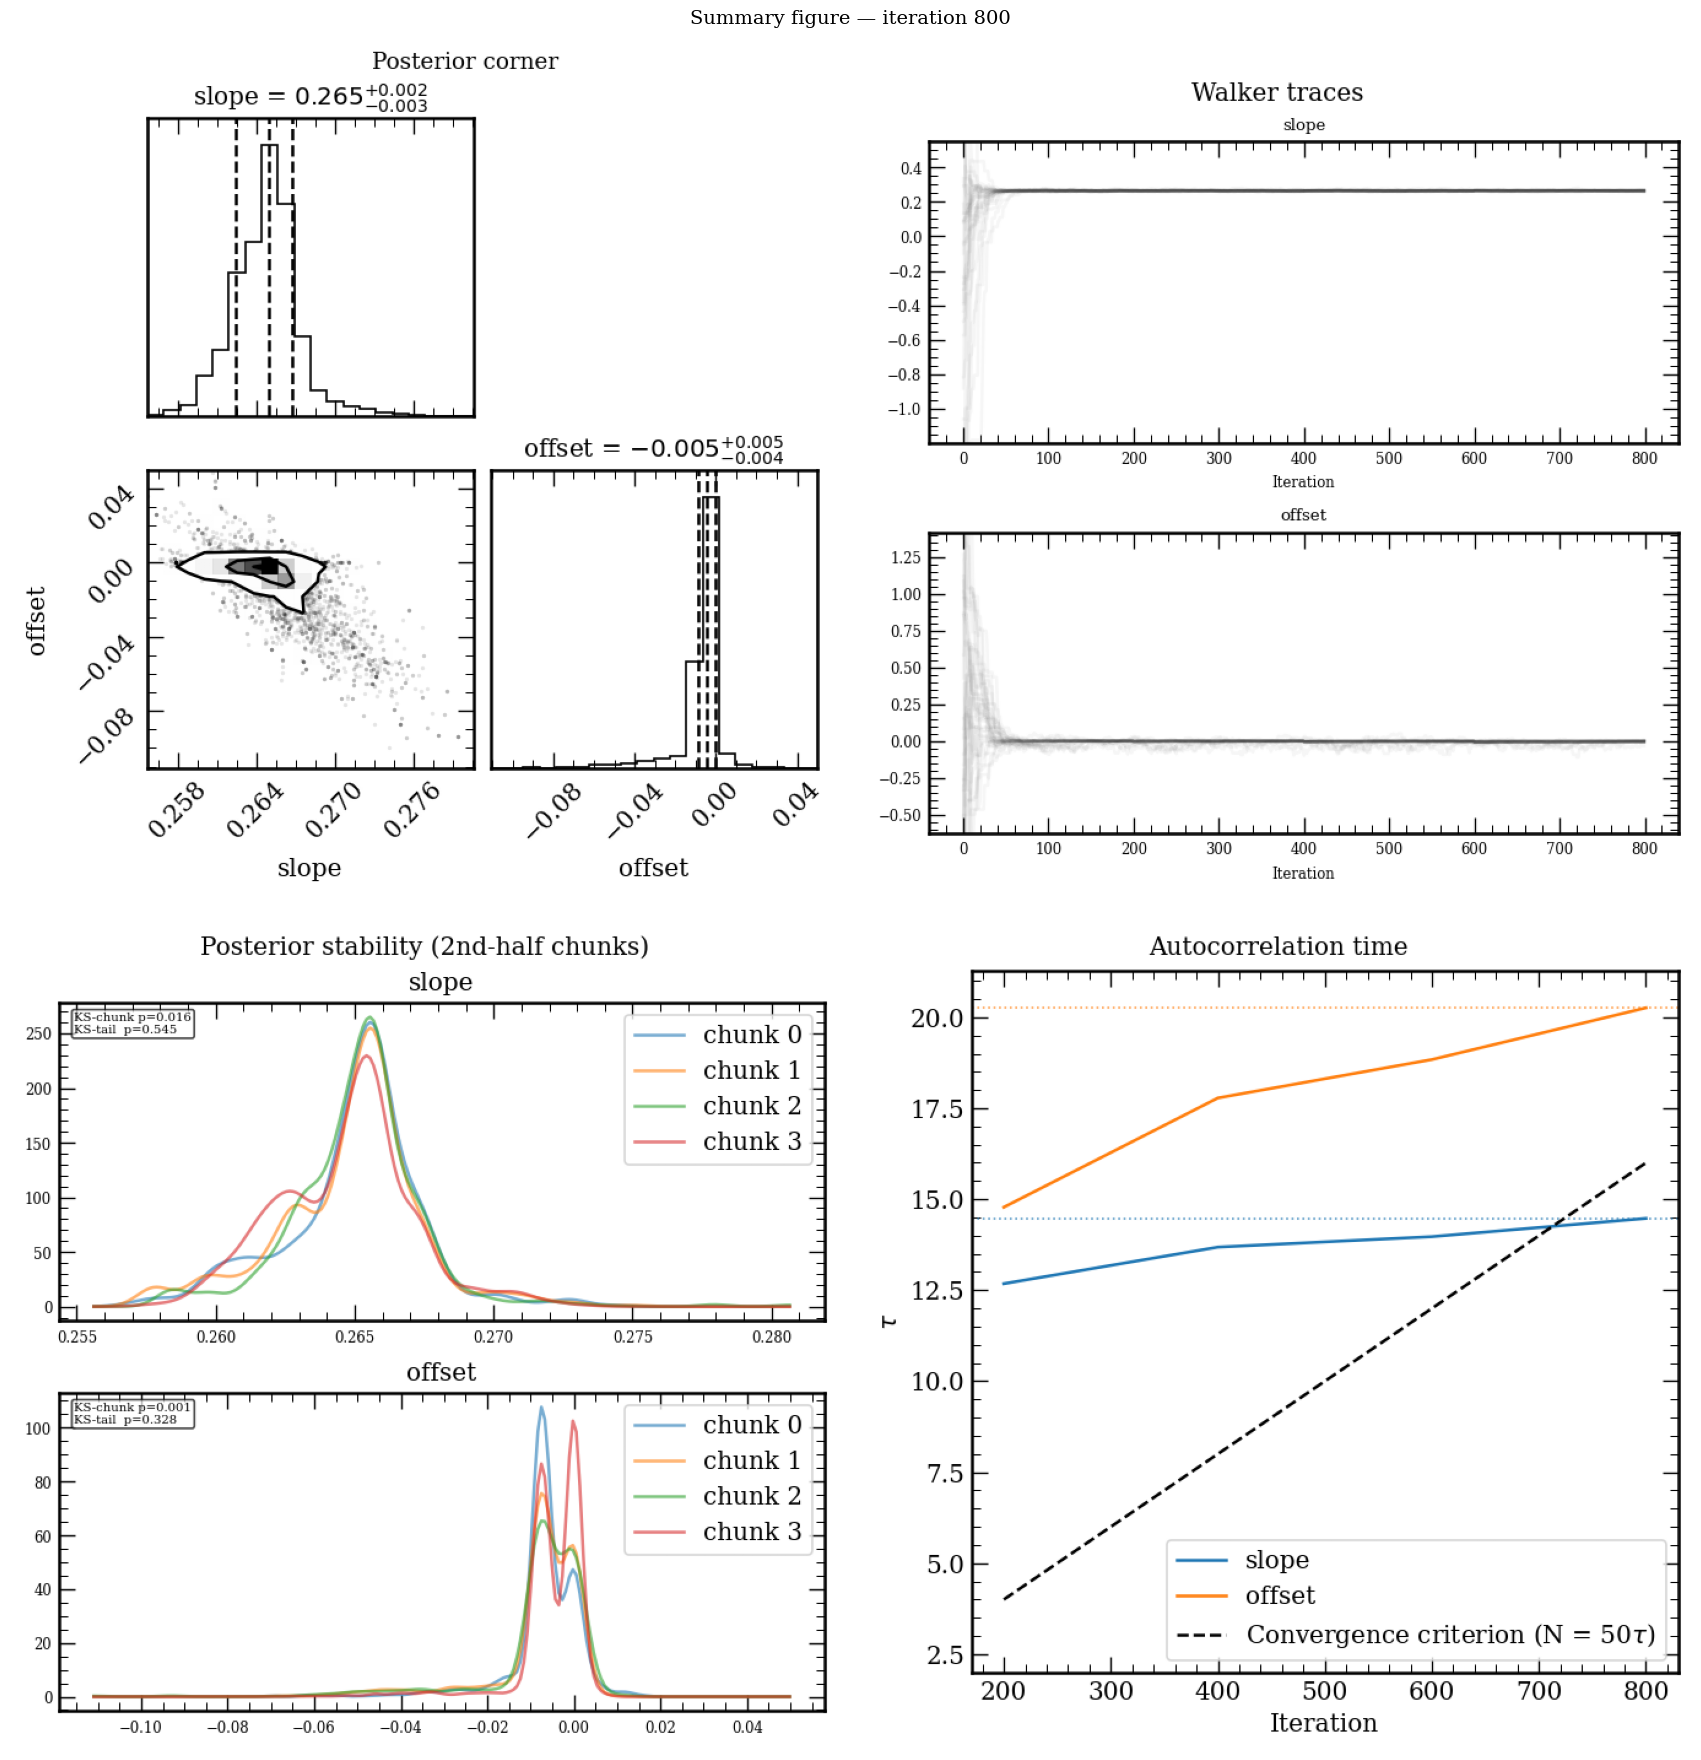

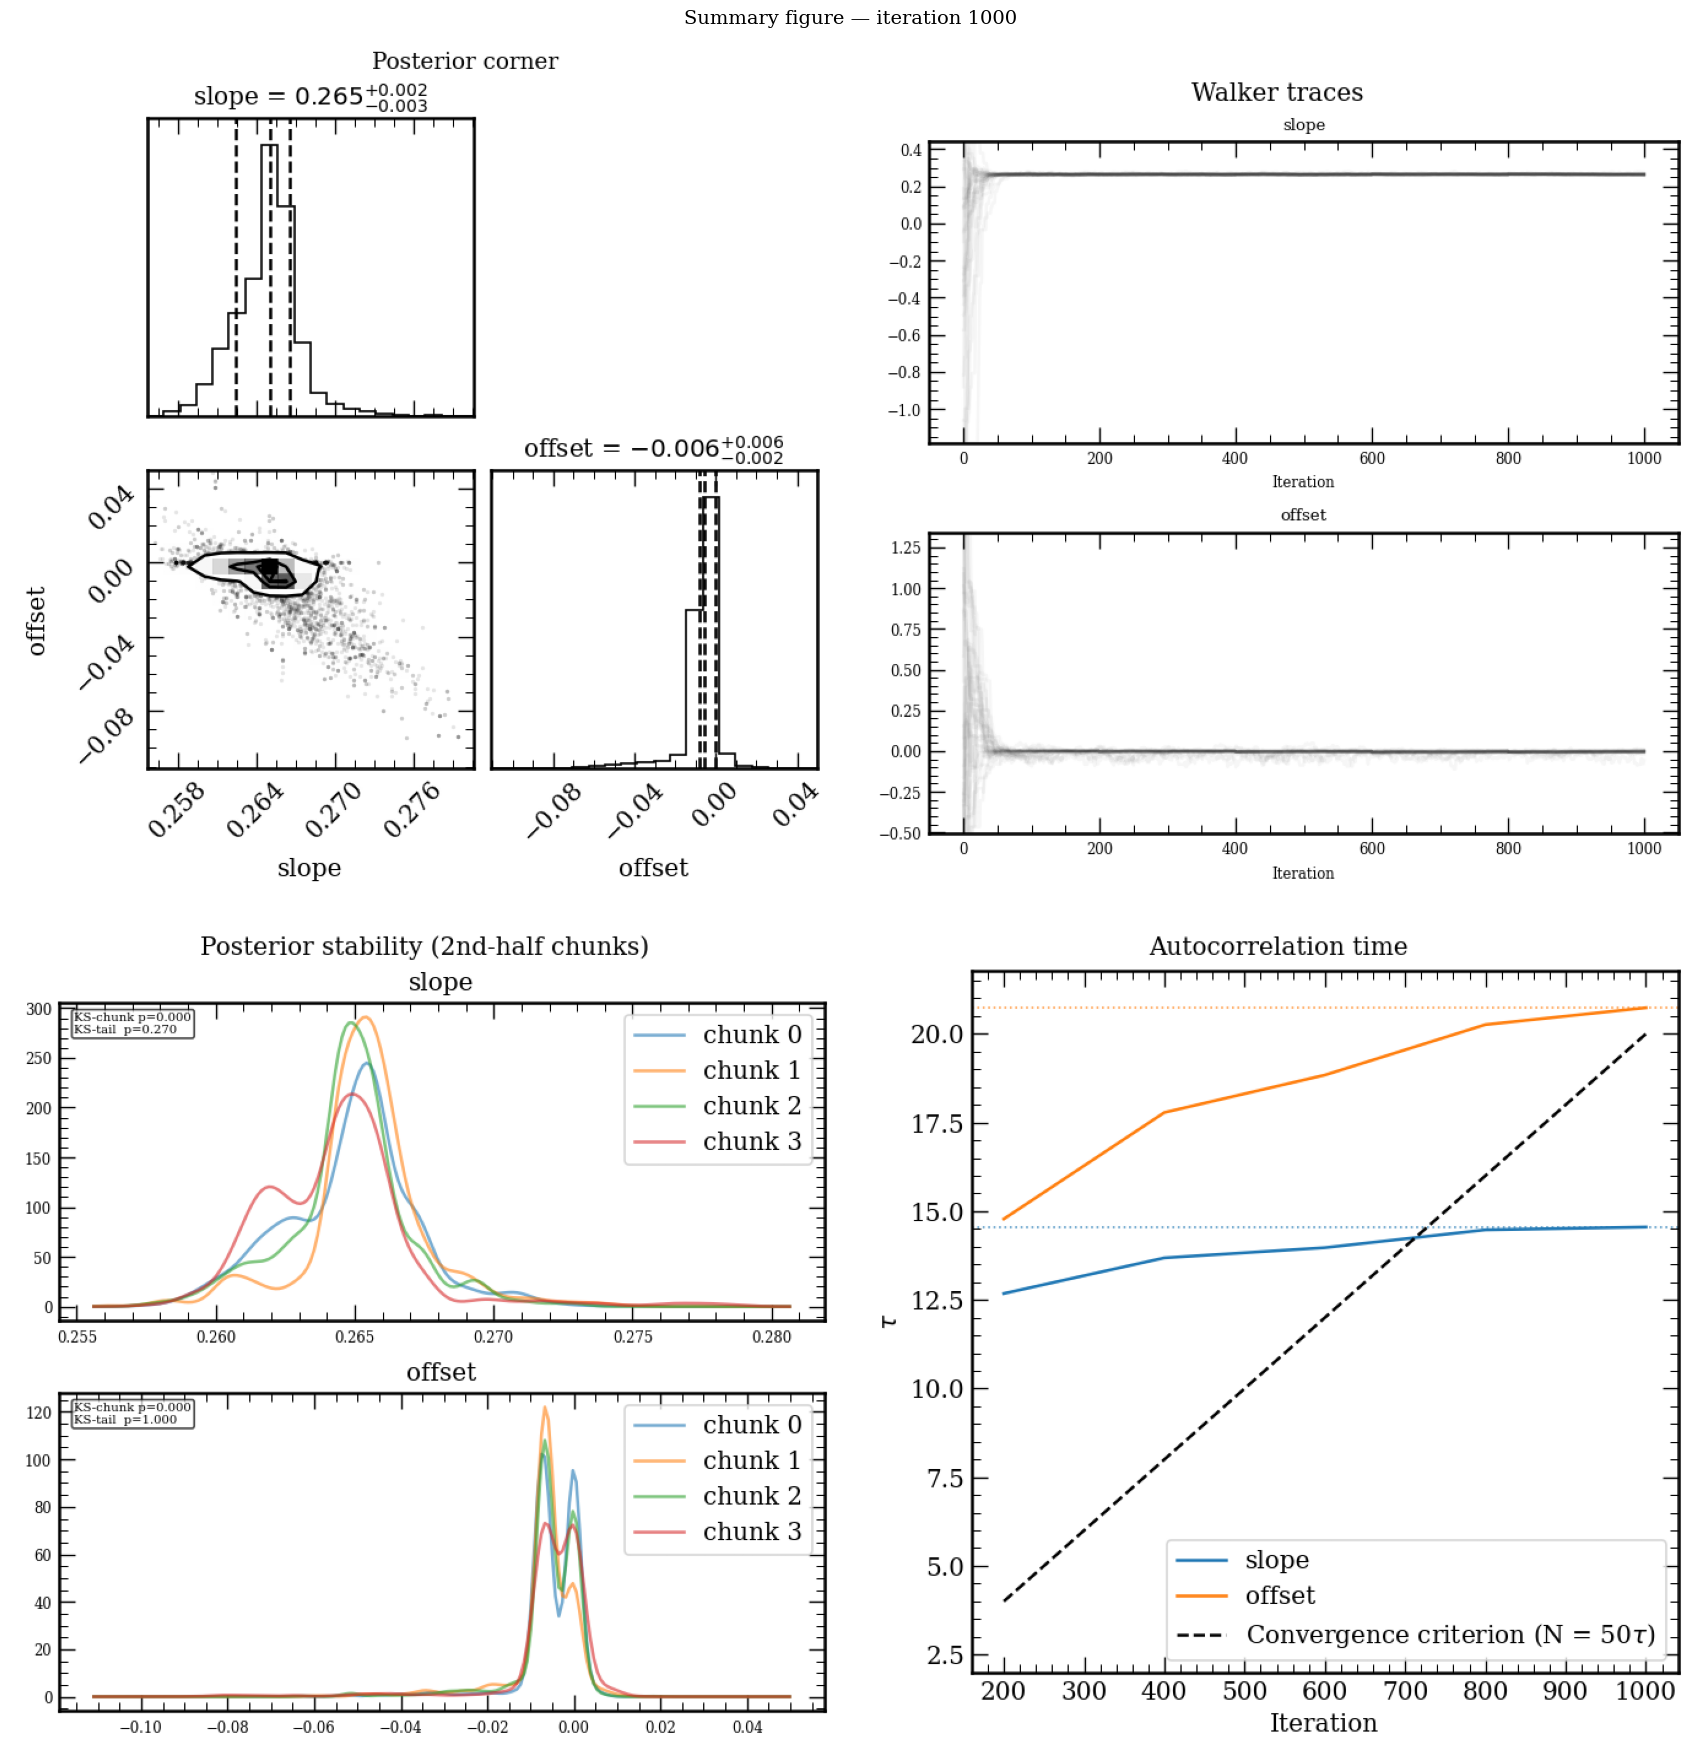

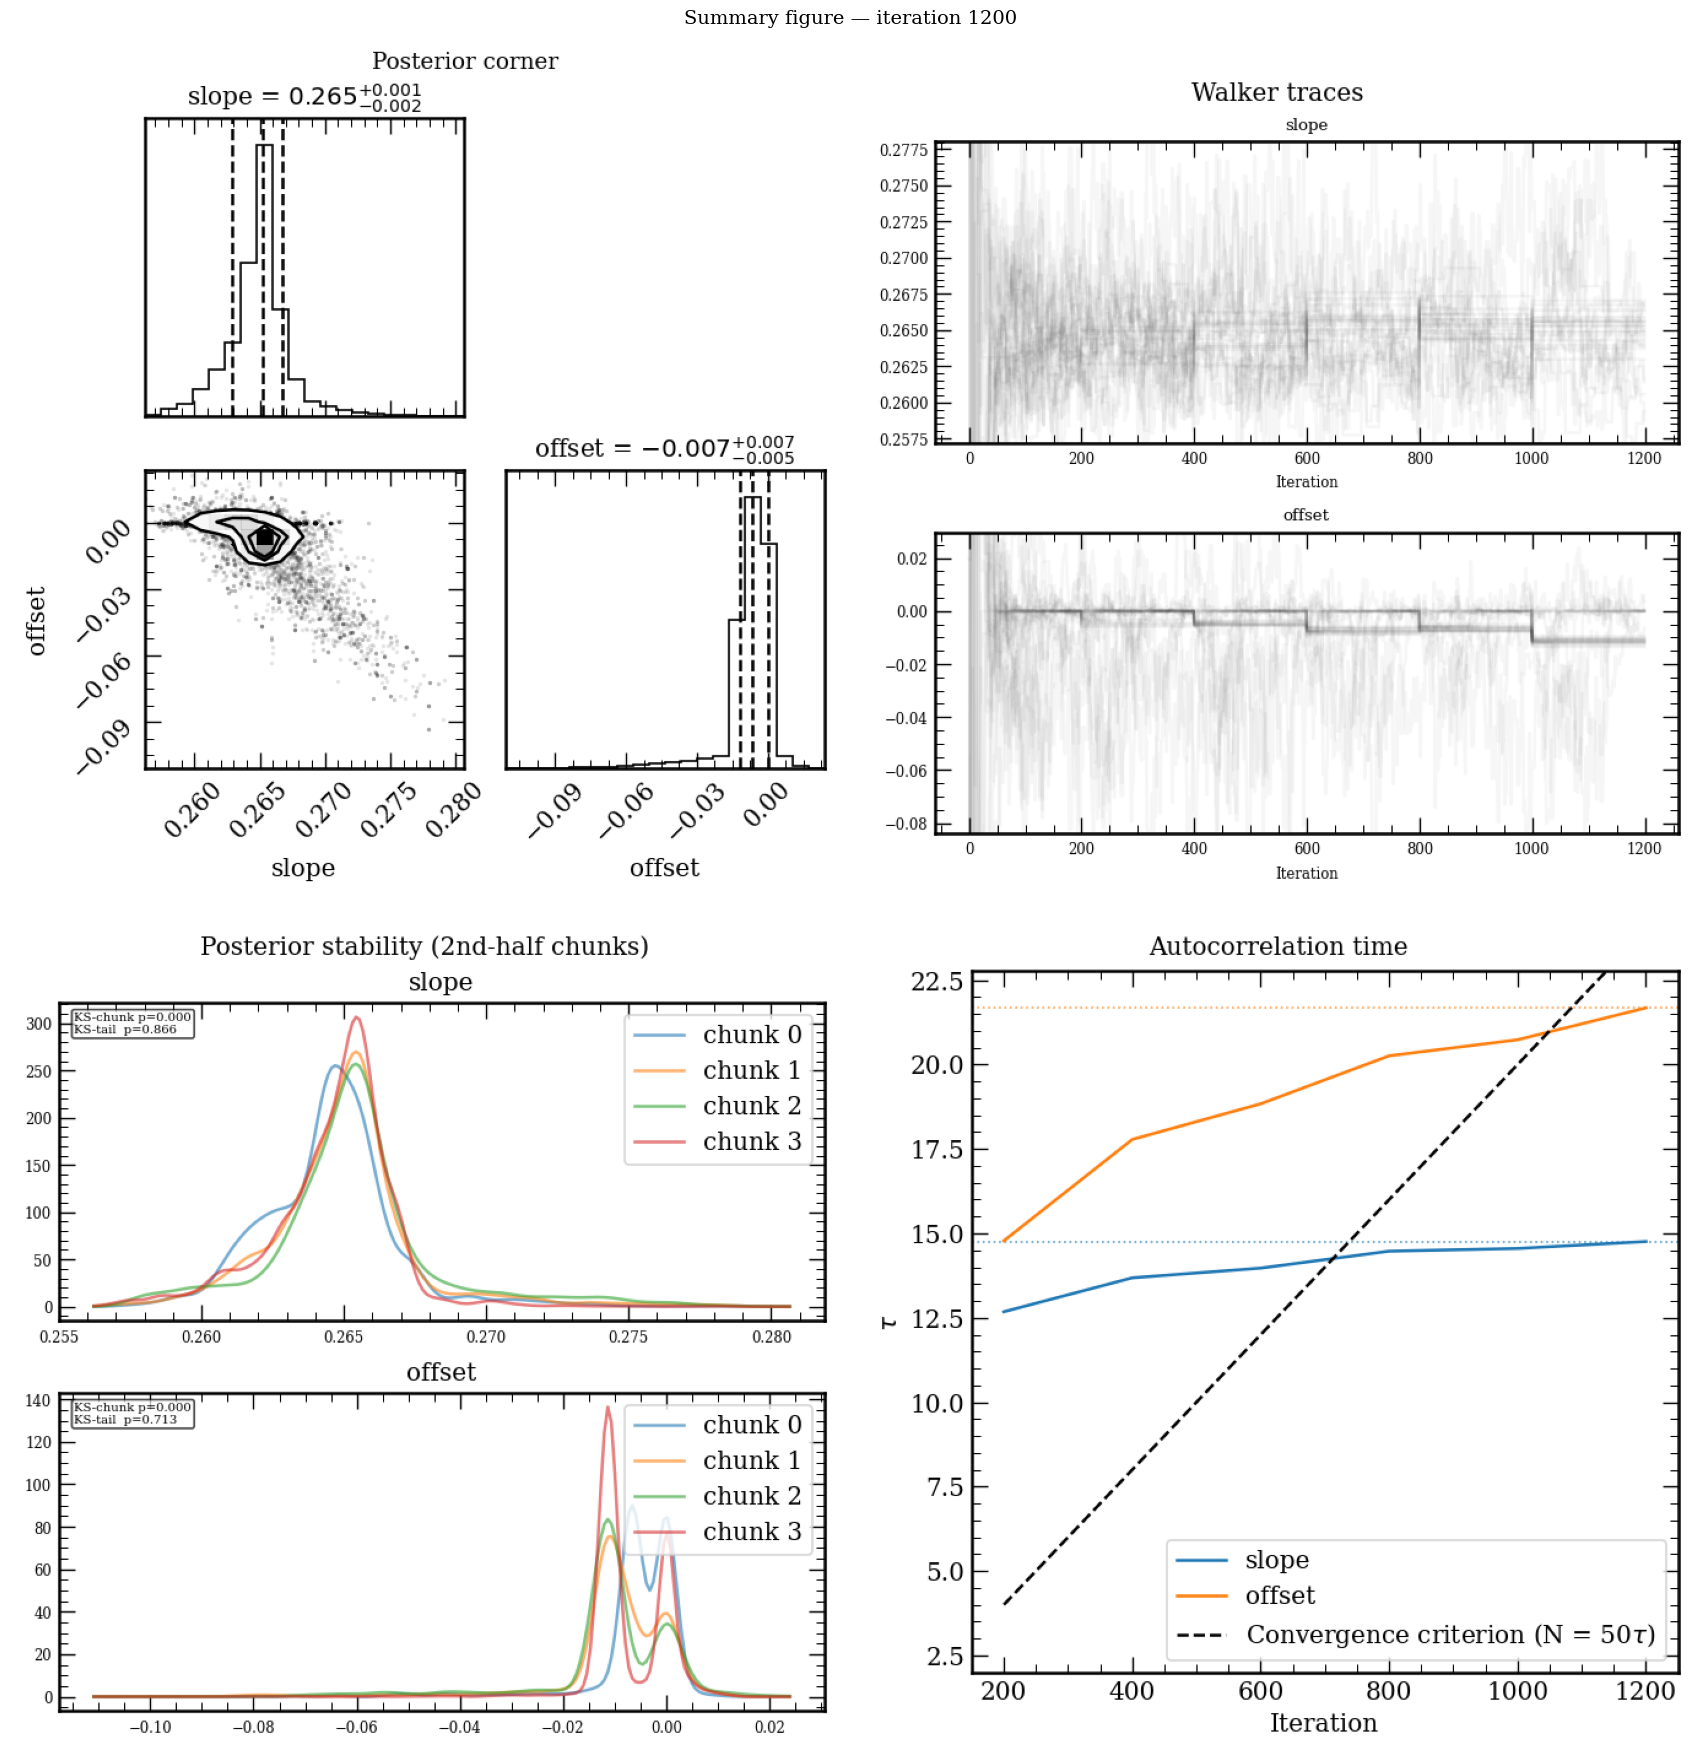

In [83]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
from IPython.display import display, HTML

def read_chain_diagnostics(filename="chain.h5", mode="last", N=None):
    """
    Read and display saved MCMC diagnostics and figures from an HDF5 chain file.

    Parameters
    ----------
    filename : str
        Path to the HDF5 file produced by run_adaptive_mcmc.
    mode : str
        "last"   — show only the most recent checkpoint.
        "sample" — show N checkpoints evenly sampled across all available ones.
        "all"    — show every checkpoint.
    N : int or None
        Number of checkpoints to show when mode="sample". Ignored otherwise.
    """
    with h5py.File(filename, "r") as f:

        # Collect all figure groups, sorted by iteration number
        fig_groups = sorted(
            [k for k in f.keys() if k.startswith("figures_")],
            key=lambda k: int(k.split("_")[1])
        )

        if len(fig_groups) == 0:
            print("No diagnostic checkpoints found in file.")
            return

        # Select which checkpoints to display
        if mode == "last":
            selected = [fig_groups[-1]]
        elif mode == "all":
            selected = fig_groups
        elif mode == "sample":
            if N is None:
                raise ValueError("Please provide N when using mode='sample'.")
            N = min(N, len(fig_groups))
            indices  = np.round(np.linspace(0, len(fig_groups) - 1, N)).astype(int)
            selected = [fig_groups[i] for i in indices]
        else:
            raise ValueError(f"Unknown mode '{mode}'. Choose from 'last', 'sample', 'all'.")

        print(f"Found {len(fig_groups)} checkpoint(s) in '{filename}'.")
        print(f"Displaying {len(selected)}: {[s.split('_')[1] for s in selected]} iterations.\n")

        for grp_name in selected:
            iteration = grp_name.split("_")[1]
            grp       = f[grp_name]

            display(HTML(f"<hr><h2 style='font-family:monospace'>Checkpoint — iteration {iteration}</h2>"))

            # ---- Print diagnostics text ----
            if "diagnostics" in grp:
                diag = grp["diagnostics"][()].decode("utf-8")
                display(HTML(f"<pre style='background:#f5f5f5; padding:10px; font-size:12px'>{diag}</pre>"))
            else:
                print(f"  [No diagnostics text saved for iteration {iteration}]")

            # ---- Show summary figure ----
            if "summary" in grp:
                buf  = io.BytesIO(grp["summary"][()])
                img  = mpimg.imread(buf)
                fig, ax = plt.subplots(figsize=(18, 18))
                ax.imshow(img)
                ax.axis("off")
                ax.set_title(f"Summary figure — iteration {iteration}", fontsize=14, pad=10)
                plt.tight_layout()
                plt.show()
            else:
                print(f"  [No summary figure saved for iteration {iteration}]")


# ======================
# USAGE EXAMPLES
# ======================

# Show only the most recent checkpoint (default):
read_chain_diagnostics("chain.h5", mode="sample", N = 10)

# Show 4 evenly spaced checkpoints across the full run:
# read_chain_diagnostics("chain.h5", mode="sample", N=4)

# Show everything:
# read_chain_diagnostics("chain.h5", mode="all")